In [1]:
# pip install idx2numpy

In [2]:
import idx2numpy
import numpy as np

In [3]:
#Loading the training images and labels
X_train = idx2numpy.convert_from_file('train-images.idx3-ubyte')
y_train = idx2numpy.convert_from_file('train-labels.idx1-ubyte')

#Loading the test images and labels
X_test = idx2numpy.convert_from_file('t10k-images.idx3-ubyte')
y_test = idx2numpy.convert_from_file('t10k-labels.idx1-ubyte')


## Filtering


In [4]:
filter=np.isin(y_train,[0,1,2])
test_filter = np.isin(y_test,[0,1,2])



X_filtered = X_train[filter]
y_filtered = y_train[filter]


X_test_filtered = X_test[test_filter]
y_test_filtered = y_test[test_filter]



## Sampling

In [5]:
def sample_data(X,y):
    
    np.random.seed(70)  # setting the seed for fixed random sampling so that accracy doent change every time
    
    selected_indices=[]
    
    
    for digit in [0,1,2]:
        available_indices = np.where(y==digit)[0]  #it returns a tuple

        chosen_indices = np.random.choice(available_indices,100,replace=False)  #replace=False no duplicate
        
        # append to list
        selected_indices.extend(chosen_indices)
    
    selected_indices=np.sort(selected_indices)
    
  
    X_sampled=X[selected_indices]
    y_sampled=y[selected_indices]
    
    return X_sampled, y_sampled



# Apply sampling
X_train_sampled,y_train_final=sample_data(X_filtered, y_filtered)
X_test_sampled,y_test_final=sample_data(X_test_filtered, y_test_filtered)



## Converting to feature vectors and normalising

In [6]:
def converrt(x):
    my_array = np.zeros((784, 300))
    for i in range(300):
        k=0
        for j in range(784):
            dj=j%28
            k=j//28
            my_array[j][i]=x[i][dj][k]/255.0
            
    return my_array



X_train_final=converrt(X_train_sampled)
X_test_final=converrt(X_test_sampled)


## MLE

In [7]:
parameters ={}

for digit in [0,1,2]:
    indx=np.where(y_train_final == digit)[0]

    class_data= X_train_final[:, indx]

    mean=np.zeros((784,1))

    for i in range(784):
        sum=0
        for j in range(100):
            sum+=class_data[i][j]
        mean[i][0]=sum/100    #100 is the class size


   

    X_cntr=class_data-mean

    sig = (X_cntr @ X_cntr.T) / 100

    # print(mean.shape)
    # print(sig.shape)

    parameters[digit]={"mean":mean,"covariance":sig}

## LDA

In [8]:
def isinvertible(sigma):
    rank=np.linalg.matrix_rank(sigma)
    if rank<784:
        return False
    return True


# not considering priors in disciminant calculation bcz all are same = 0.33
def discriminant(meu,x_i,sigma_inv):
    omega= sigma_inv @ meu

    omega_t=omega.T

    b= -(meu.T@sigma_inv@meu)/2

    return (omega_t@ x_i+b).item()




def lda(sigma):
    if(not isinvertible(sigma)):
        sigma +=0.0001*np.identity(784)

    sigma_inv = np.linalg.inv(sigma)
    tot=0

    d={}
    prediction=[]
    for i in range(300):
        x_i = X_test_final[:,i]
        for j in parameters:
            meu = parameters[j]["mean"]
            d[j]=discriminant(meu,x_i,sigma_inv)
        mx=-np.inf
        cls=-1
        for c,scor in d.items():
            if(scor>mx):
                cls=c
                mx=scor
        prediction.append(cls)
        if y_test_final[i]==cls:
            tot+=1
    return prediction,tot


# here i am taking the common covariance matrix as mean of all the matrices.
sigma = (parameters[0]["covariance"]+parameters[1]["covariance"]+parameters[2]["covariance"])/3



predicted_LDA,total_eq=lda(sigma)




# print(predicted_LDA)

print("Accuracy: ",total_eq/300) # 300   as 300 are the total samples

Accuracy:  0.9066666666666666


### LDA Discriminant value of sample test point

In [9]:
sample_idx = 0
x_sample = X_test_final[:,sample_idx]
true_cls=y_test_final[sample_idx]
sigma = (parameters[0]["covariance"]+parameters[1]["covariance"]+parameters[2]["covariance"])/3
if(not isinvertible(sigma)):
        sigma +=0.0001*np.identity(784)
    


print("Sample Point for LDA")
print(f"Discriminant Values for Test Sample {sample_idx} (True Label: {true_cls})")

for cls in [0,1,2]:
    mu=parameters[cls]["mean"]
    sigma_inv=np.linalg.inv(sigma)

    score=discriminant(mu,x_sample,sigma_inv)
    
    print(f"Class {cls} Score: {score:.4f}")

Sample Point for LDA
Discriminant Values for Test Sample 0 (True Label: 1)
Class 0 Score: -392.4773
Class 1 Score: 745.1333
Class 2 Score: 183.1917


#  QDA

In [10]:
def isinvertible(sigma):
    rank = np.linalg.matrix_rank(sigma)
    if rank<784:
        return False
    return True


# not considering priors in disciminant calculation bcz all are same = 0.33
def discriminant(sigma,meu,x_i,sigma_inv):
    sign,sigma_log_det=np.linalg.slogdet(sigma)
    omega= sigma_inv @ meu
    W=-sigma_inv/2

    omega_t=omega.T

    b= (-(meu.T @ sigma_inv @ meu)/2)-(sigma_log_det/2)
    return (x_i.T @ W @ x_i+ omega_t @ x_i + b).item()



# finding inverse
stats={}

for j in parameters:
    sigma = parameters[j]["covariance"].copy()
    if(not isinvertible(sigma)):
        sigma +=0.0001*np.identity(784)
    parameters[j]["covariance"]=sigma
    sigma_inv = np.linalg.inv(sigma)
    stats[j]=sigma_inv

    
    




def qda():
    
    d={}
    tot=0
    prediction=[]
    for i in range(300):
        for j in parameters:
            x_i = X_test_final[:,i]
            meu = parameters[j]["mean"]
            sigma = parameters[j]["covariance"].copy()
            sigma_inv=stats[j]
            d[j]=discriminant(sigma,meu,x_i,sigma_inv)
        mx=-np.inf
        cls=-1
        for c,scor in d.items():
            if(scor>mx):
                cls=c
                mx=scor
        if y_test_final[i]==cls:
            tot+=1
        prediction.append(cls)
    return prediction,tot



predicted_QDA,total_eq=qda()


# print(predicted_QDA)

print("Accuracy: ",total_eq/300) # 300 as 300 are the total samples

Accuracy:  0.99


### QDA Discriminant value of sample test point

In [11]:
sample_idx=0
x_sample = X_test_final[:,sample_idx]
true_cls=y_test_final[sample_idx]


print("Sample Point for QDA")
print(f"Discriminant Values for Test Sample {sample_idx} (True Label: {true_cls})")

for cls in [0,1,2]:
    mu=parameters[cls]["mean"]
    sigma=parameters[cls]["covariance"] 
    sigma_inv=stats[cls] 

    score=discriminant(sigma,mu,x_sample,sigma_inv)
    
    print(f"Class {cls} Score: {score:.4f}")
    


Sample Point for QDA
Discriminant Values for Test Sample 0 (True Label: 1)
Class 0 Score: -95031.6685
Class 1 Score: -3384.7894
Class 2 Score: -58304.7239


# Plotting

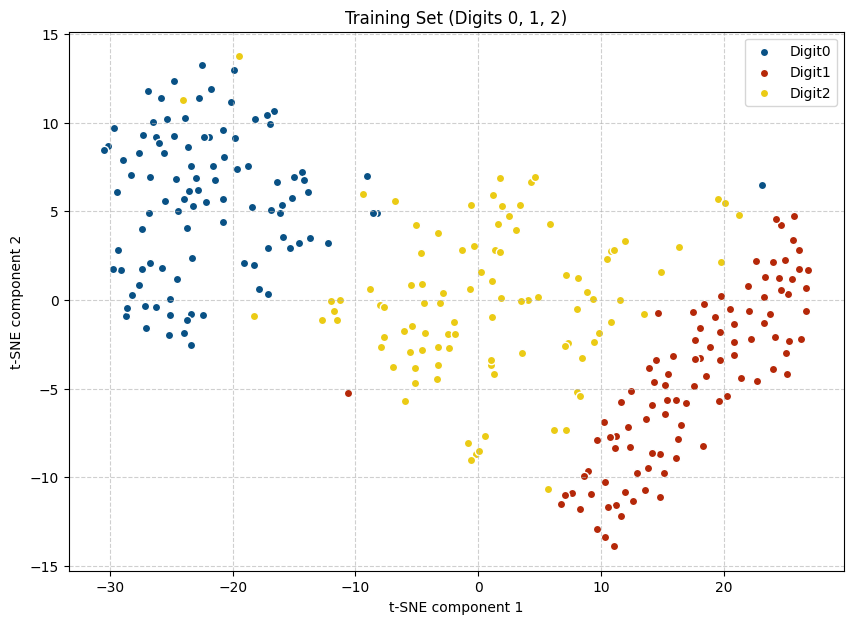

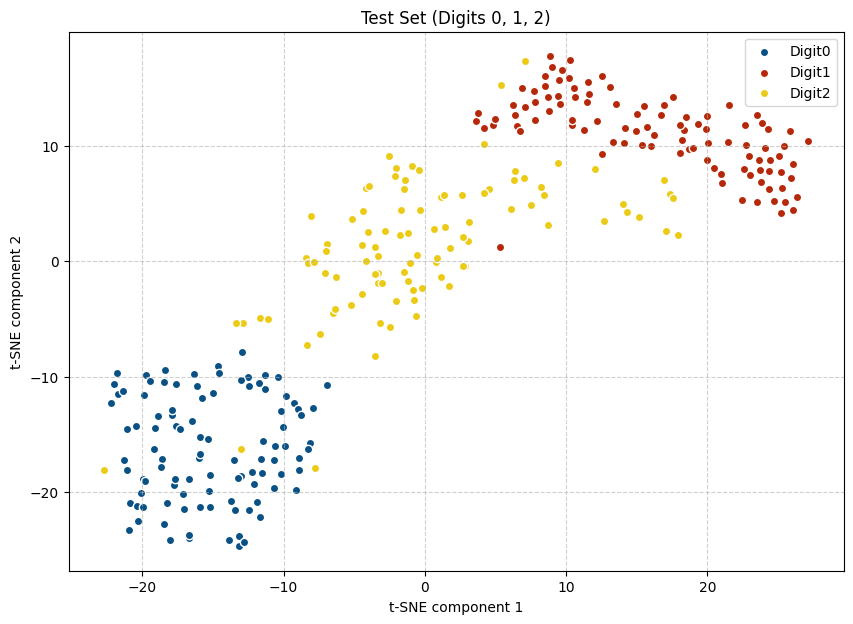

In [12]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def plot_tsne(data,cls,title):
    # t-SNE take input as (n_samples,n_features) our data is currently (784,300) so take transpose
    tsne=TSNE(n_components=2,random_state=42,perplexity=30)
    X_tsne=tsne.fit_transform(data.T)

    plt.figure(figsize=(10,7))
    colors=["#095185", "#b52809", "#EBCB15"] #colors for 0,1,2 different classes
    
    for digit in [0,1,2]:
        indx=(cls==digit)
        plt.scatter(X_tsne[indx,0],X_tsne[indx,1],label=f"Digit{digit}",edgecolors='w',color=colors[digit])
    
    plt.title(title)
    plt.legend()
    plt.xlabel("t-SNE component 1")
    plt.ylabel("t-SNE component 2")
    plt.grid(True,linestyle='--',alpha=0.6)
    plt.show()


plot_tsne(X_train_final, y_train_final,"Training Set (Digits 0, 1, 2)")
plot_tsne(X_test_final, y_test_final, "Test Set (Digits 0, 1, 2)")